<a href="https://colab.research.google.com/github/May-o-nnaise/CPSMA-4313-MS/blob/main/DataVizQuiz13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-colab-selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [38]:
import requests
from bs4 import BeautifulSoup
import pandas as pa

url = "https://wiki.uooutlands.com/Houses"

r = requests.get(url)
soup = BeautifulSoup(r.text)

soup.find_all('table')

[<table class="wikitable sortable" style="text-align: center">
 <tbody><tr>
 <th>Display Name
 </th>
 <th>Picture
 </th>
 <th>Price
 </th>
 <th>Size X
 </th>
 <th>Size Y
 </th>
 <th>Floors
 </th>
 <th>Secures
 </th>
 <th>Lockdowns
 </th>
 <th>Vendors
 </th></tr>
 <tr>
 <td><a href="/Log_and_Stone_Retreat" title="Log and Stone Retreat">Log and Stone Retreat</a>
 </td>
 <td><span class="mw-default-size" typeof="mw:File"><a href="/Log_and_Stone_Retreat" title="Log and Stone Retreat"><img class="mw-file-element" decoding="async" height="240" src="/images/2/21/logandstoneretreat00a.jpg" width="169"/></a></span>
 </td>
 <td>3,550,000
 </td>
 <td>19
 </td>
 <td>22
 </td>
 <td>2
 </td>
 <td>19
 </td>
 <td>3,325
 </td>
 <td>38
 </td></tr>
 <tr>
 <td><a href="/Andarian_Abode" title="Andarian Abode">Andarian Abode</a>
 </td>
 <td><span class="mw-default-size" typeof="mw:File"><a href="/Andarian_Abode" title="Andarian Abode"><img class="mw-file-element" decoding="async" height="240" src="/images/e

I chose to use the the table for all the houses in UO Outlands server.

In [34]:
from selenium.webdriver.chrome.options import Options
import google_colab_selenium as gs

custom_options = Options()
custom_options.add_argument("--headless")
# Add your custom options here

driver = gs.Chrome(options=custom_options)

<IPython.core.display.Javascript object>

In [39]:
from io import StringIO

driver.get(url)
soup = BeautifulSoup(driver.page_source, 'html.parser')
tables = soup.find_all('table')
#tables
pa.read_html(StringIO(str(tables[0])))[0]

,Display Name,Picture,Price,Size X,Size Y,Floors,Secures,Lockdowns,Vendors
0,Log and Stone Retreat,NaN,3550000,19,22,2.0,19,3325.0,38.0
1,Andarian Abode,NaN,950000,16,10,2.0,10,1750.0,20.0
2,Andarian Barn,NaN,350000,11,10,2.0,6,1050.0,12.0
3,Andarian Block House,NaN,250000,9,11,2.0,5,875.0,10.0
4,Andarian Bluestone And Slate,NaN,550000,13,11,2.0,8,1400.0,16.0
...,...,...,...,...,...,...,...,...,...
218,Wooden Houseboat East,NaN,"5,000,000 Doubloons",10,18,1.0,10,1750.0,20.0
219,Wooden Houseboat,NaN,"5,000,000 Doubloons",18,10,1.0,10,1750.0,20.0
220,Wooden Square House,NaN,150000,9,9,2.0,4,700.0,8.0
221,Wooden Two Story Houseboat East,NaN,"10,000,000 Doubloons",10,22,1.5,14,2450.0,28.0


I got the google colab to make it an interactive table so that was pretty cool Im not sure if it will work on github though. The table has some weird data points like the number of floors. Some of them have decimal values in the floors like "2.5" floors which just means one of the stories isnt a full square like the foundation or perhaps it has an extension like imagine a castle with towers on its corners, would that be another floor? probably not so they use decimal values and dont ask me what happens if they add up to a full number because idk.

In [40]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By

# Wait for the link to be clickable and then click it
try:
    small_marble_workshop_link = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.LINK_TEXT, "Small Marble Workshop"))
    )
    small_marble_workshop_link.click()
    print("Successfully clicked on 'Small Marble Workshop'.")
    # Optionally, you can print the new URL to confirm navigation
    print("Current URL after clicking: ", driver.current_url)
except Exception as e:
    print(f"An error occurred while trying to click the link: {e}")

Successfully clicked on 'Small Marble Workshop'.
Current URL after clicking:  https://wiki.uooutlands.com/Small_Marble_Workshop


I had gemeni make this code by just asking it to make selenium click on small marble workshop and it did this for me.

The link I had selenium click on was the small marble workshop link. I did this because its the house I have in the game and that game does housing in a really interesting game because your house is physically in the world, they dont just make some kind of island with your house on it like they do in RuneScape its actually out in the world and players can see it and even walk inside in certain cases.

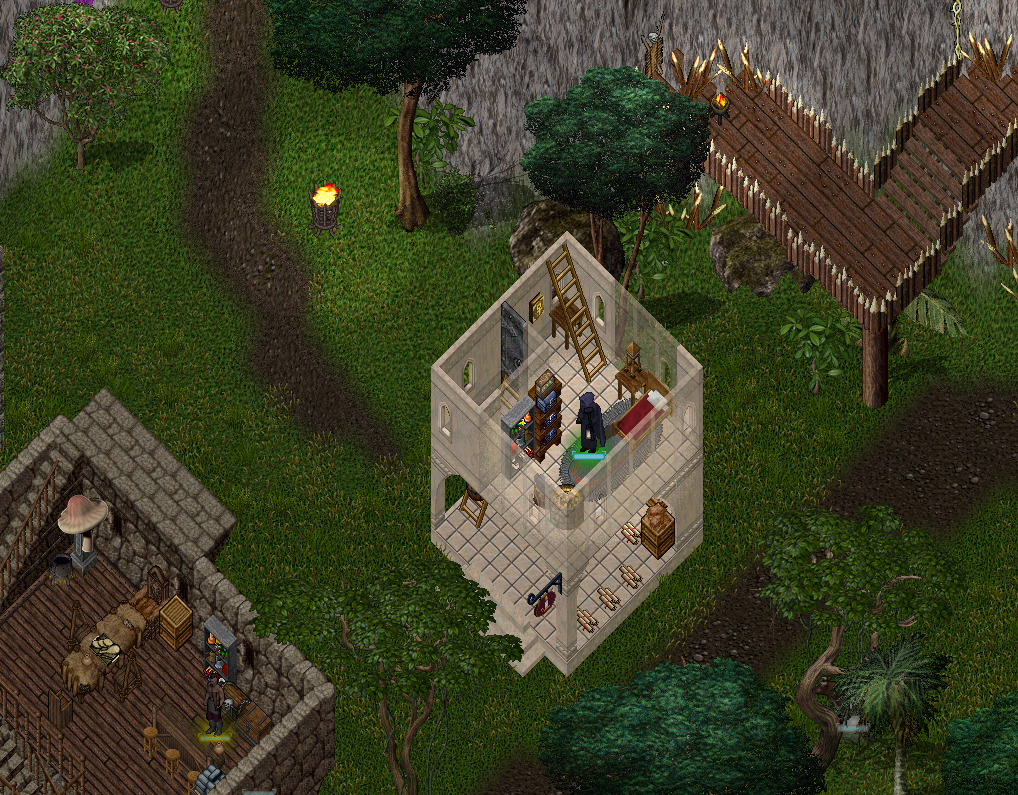

Heres is my digital real estate. Im basically doxxing myself in an online video game. Now the whole world knows where I live in a 30 year old wizard game.

In [41]:
driver.quit()